In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from fenics import *
from pathlib import Path
from utils.colors import CMAP
from utils.utils import progress_bar
from utils.mesh_utils import get_square_f, get_L_mesh, get_square_mesh
from utils.exact_forward_operator import ExactForwardOperator, solve_explicit
from algorithms.matrix_free_rsvd import MatrixFreeRSVD, tikhonov_solver, get_approximate_W
from fenics import FunctionSpace, Function
from utils.metrics import (
    vec_to_matrix, compute_cv_mask, SpaceIndexing, error_centroid,
    error_movers, error_iou, error_ssim, rectangular_interpolation
)

SEED = 15

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
n = 64
problem_params = {
    'I': {'mesh': get_square_mesh, 'n': n, 'width': 0.15, 'height': 0.15,
          'x0': [0.2], 'y0': [0.2]},
    'II': {'mesh': get_square_mesh, 'n': n, 'width': 0.15, 'height': 0.15,
           'x0': [0.1, 0.75, 0.15], 'y0': [0.1, 0.75, 0.70]},
    'III': {'mesh': get_L_mesh, 'n': n, 'width': 0.25, 'height': 0.25,
            'x0': [0.2, 1.55], 'y0': [0.2, 0.55]}
}

def get_source(V_h, x0_list, y0_list, width, height):
    x = np.zeros(V_h.dim())
    for x0, y0 in zip(x0_list, y0_list):
        f = get_square_f(V_h, x0=x0, y0=y0, w=width, h=height)
        x += f.vector().get_local()

    f = Function(V_h)
    f.vector()[:] = x
    return f, x


def problem_setup(params, lambda_):
    # Function space setup
    mesh = params['mesh'](params['n'])
    V_h = FunctionSpace(mesh, 'CG', 1)
    rsvd = MatrixFreeRSVD(V_h)

    # Source setup
    f, x = get_source(
        V_h, params['x0'], params['y0'], 
        params['width'], params['height']
    )
    y = rsvd.apply_K(x)

    # Full rank solution
    exact = ExactForwardOperator(V_h)
    f_hat = solve_explicit(operator=exact, w=exact.get_weights(), y=y, lambda_=lambda_)
    x_hat = f_hat.vector().get_local()

    problem = {'V_h': V_h, 'rsvd': rsvd, 'f': f, 'x': x, 'y': y, 'f_hat': f_hat, 'x_hat': x_hat}
    return problem


def problems_setup(problem_params, lambda_):
    problems =  {}
    for key, params in problem_params.items():
        print(f"Setting up problem {key}: ", end='')
        pb = problem_setup(params, lambda_)
        print(f" N_b={pb['rsvd'].N_b}, N={pb['rsvd'].N} (done)")
        problems[key] = pb
    return problems


In [3]:
problems = problems_setup(problem_params, lambda_=1e-4)

Setting up problem I:  N_b=256, N=4225 (done)
Setting up problem II:  N_b=256, N=4225 (done)
Setting up problem III:  N_b=288, N=6127 (done)


In [ ]:
def relative_segmentation(x: np.ndarray, tau: float) -> np.ndarray:
    """Compute the relative threshold (fraction of max) segmentation."""
    return x >= tau * np.max(x)


def error_iou(mask_a: np.ndarray, mask_b: np.ndarray) -> float:
    """Intersection over Union between two binary masks."""
    intersection = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    if union == 0:
        return 1.0
    return intersection / union


def error_auc_iou(
        x: np.ndarray, x_hat: np.ndarray, tau_range: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    x, np.array         : ground truth
    x_hat, np.array     : tikhonov solution
    tau_range, np.array : thresholds as fraction of max

    returns: (auc_iou, tau_max, ious)
    """
    ious = np.zeros(len(tau_range))

    for i, tau in enumerate(tau_range):
        mask = relative_segmentation(x, tau)
        mask_hat = relative_segmentation(x_hat, tau)
        ious[i] = error_iou(mask, mask_hat)

    return np.trapz(ious, tau_range), tau_range[np.argmax(ious)], ious


def tau_experiment(problem_id, num):
    p = problems[problem_id]
    tau_range = np.linspace(0.1, 1, num=num)
    auc_iou, tau_max, ious = error_auc_iou(x=p['x'], x_hat=p['x_hat'], tau_range=tau_range)
    return tau_range, auc_iou, tau_max, ious


results = {}
for idx in ['I', 'II', 'III']:
    tau_range, auc_iou, tau_max, ious = tau_experiment(idx, 100)
    results[idx] = {'tau_range': tau_range, 'ious': ious, 'auc_iou': auc_iou, 'tau_max': tau_max}

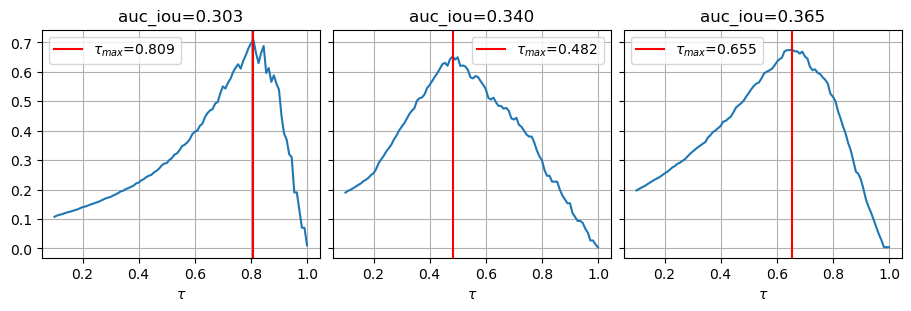

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3), constrained_layout=True, sharey=True)

for ax, res in zip(axes.flatten(), results.values()):
    tau_max = res['tau_max']
    auc_iou = res['auc_iou']

    ax.plot(res['tau_range'], res['ious'])
    ax.axvline(tau_max, c='r', label=f'$\\tau_{{max}}$={tau_max:.3f}')

    ax.set_title(f'auc_iou={auc_iou:.3f}')
    ax.set_xlabel('$\\tau$')
    ax.legend()
    ax.grid(0.5)

plt.show()